https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset

## Importing libs

In [1]:
import sys
sys.path.append('..')  # Add parent directory to path
import pandas as pd
import numpy as np
from db_setup.query import query_bigquery_table
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
import seaborn as sns

# Importing Dummyclassifier for baseline model and logistic regression for the actual model
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Importing RandomForestClassifier and XGBClassifier for additional models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Importing Scalers for feature scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Libs to plot AUC-ROC curve
from sklearn.metrics import roc_curve, auc

# Lib for pr-AUC curve
from sklearn.metrics import precision_recall_curve, average_precision_score

# MLflow imports
import mlflow

# NN
import torch
import torch.nn as nn
import torch.optim as optim


# Importing SMOTE for handling class imbalance
from imblearn.over_sampling import SMOTE

SEED = 42

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## MLFlow settings

In [2]:
mlflow.set_tracking_uri("file:///c:/Users/vc/Documents/MLENG_FIAP/fase_1/Gustavo/mlruns")

In [3]:
# Set the experiment name
mlflow.set_tracking_uri("file:///c:/Users/vc/Documents/MLENG_FIAP/mlruns")
mlflow.set_experiment("Telco-Churn-Prediction")

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:///c:/Users/vc/Documents/MLENG_FIAP/mlruns/582674075718407240', creation_time=1775917117851, experiment_id='582674075718407240', last_update_time=1775917117851, lifecycle_stage='active', name='Telco-Churn-Prediction', tags={}, trace_location=None, workspace='default'>

## Initial Visualization of Data

In [67]:
#df = query_bigquery_table()
df = pd.read_excel(r"C:\Users\vc\Documents\MLENG_FIAP\fase_1\Gustavo\db_setup\Telco_customer_churn.xlsx")
print(df.head())

   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Monthly Charges Tota

In [68]:
df.shape

(7043, 33)

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

## Checking for empty, nan, null values and zeros

In [70]:
for column in df.columns:
    empty_count = df[df[column] == ""].shape[0]
    empty_space_count = df[df[column] == " "].shape[0]
    null_count = df[df[column].isnull()].shape[0]
    nan_count = df[df[column].isna()].shape[0]
    zero_count = df[df[column] == 0].shape[0]

    if empty_count > 0:
        print(f'Empty values in {column}: {empty_count}')
    if empty_space_count > 0:
        print(f'Empty spaces in {column}: {empty_space_count}')
    if null_count > 0:
        print(f'Null values in {column}: {null_count}')
    if nan_count > 0:
        print(f'Nans in {column}: {nan_count}')
    if zero_count > 0:
        print(f'Zeros in {column}: {zero_count}')

Zeros in Tenure Months: 11


Empty spaces in Total Charges: 11
Zeros in Churn Value: 5174
Null values in Churn Reason: 5174
Nans in Churn Reason: 5174


### Adjusting Total Charges

In [71]:
df[df['Total Charges'] == " "]['Tenure Months']

2234    0
2438    0
2568    0
2667    0
2856    0
4331    0
4687    0
5104    0
5719    0
6772    0
6840    0
Name: Tenure Months, dtype: int64

In [72]:
mean_total_charges = df[df['Total Charges'] != ' ']['Total Charges'].astype(float).mean()
print(f'Mean Total Charges: {mean_total_charges}')

Mean Total Charges: 2283.3004408418656


In [73]:
median_total_charges = df[df['Total Charges'] != ' ']['Total Charges'].astype(float).median()
print(f'Median Total Charges: {median_total_charges}')

Median Total Charges: 1397.475


(array([1525.,  672.,  512.,  458.,  454.,  316.,  276.,  201.,  194.,
         170.,  179.,  159.,  147.,  162.,  145.,  136.,  159.,  117.,
         121.,  146.,  128.,  108.,  102.,  100.,   83.,   74.,   66.,
          64.,   36.,   22.]),
 array([  18.8       ,  307.66666667,  596.53333333,  885.4       ,
        1174.26666667, 1463.13333333, 1752.        , 2040.86666667,
        2329.73333333, 2618.6       , 2907.46666667, 3196.33333333,
        3485.2       , 3774.06666667, 4062.93333333, 4351.8       ,
        4640.66666667, 4929.53333333, 5218.4       , 5507.26666667,
        5796.13333333, 6085.        , 6373.86666667, 6662.73333333,
        6951.6       , 7240.46666667, 7529.33333333, 7818.2       ,
        8107.06666667, 8395.93333333, 8684.8       ]),
 <BarContainer object of 30 artists>)

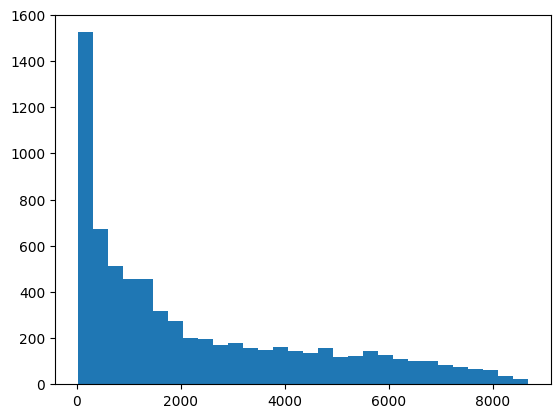

In [74]:
# Histogram of TotalCharges
plt.hist(df[df['Total Charges'] != ' ']['Total Charges'].astype(float), bins=30)

In [75]:
df['Total Charges'] = df['Total Charges'].replace(" ", 0).astype(float)

C:\Users\vc\AppData\Local\Temp\ipykernel_7188\821220724.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Total Charges'] = df['Total Charges'].replace(" ", 0).astype(float)


In [76]:
df['Total Charges'] = df['Total Charges'].astype(float)

## Checking feature distribution

In [77]:
for column in df.columns:
    if column == 'CustomerID' or column == 'Churn Value':
        continue
    if df[column].dtype == 'object':
        print(f"Value counts for {column}:")
        print(df[[column, 'Churn Value']].value_counts(normalize=True))
    else:
        print(f"Statistics for {column}:")
        print(df[[column, 'Churn Value']].groupby('Churn Value')[column].describe())
    
    print("\n" + "="*50 + "\n")

Statistics for Count:
              count  mean  std  min  25%  50%  75%  max
Churn Value                                            
0            5174.0   1.0  0.0  1.0  1.0  1.0  1.0  1.0
1            1869.0   1.0  0.0  1.0  1.0  1.0  1.0  1.0


Value counts for Country:
Country        Churn Value
United States  0              0.73463
               1              0.26537
Name: proportion, dtype: float64


Value counts for State:
State       Churn Value
California  0              0.73463
            1              0.26537
Name: proportion, dtype: float64


Value counts for City:
City         Churn Value
Los Angeles  0              0.030527
San Diego    0              0.014198
Los Angeles  1              0.012779
San Jose     0              0.011785
Sacramento   0              0.011643
                              ...   
Alpaugh      0              0.000142
Mentone      1              0.000142
Mendota      1              0.000142
Yorkville    1              0.000142
Yermo        1   

In [78]:
df[['Churn Value', 'Churn Label']].value_counts()

Churn Value  Churn Label
0            No             5174
1            Yes            1869
Name: count, dtype: int64

In [79]:
columns = df.columns.tolist()
columns

['CustomerID',
 'Count',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Churn Reason']

## Correlation matrix

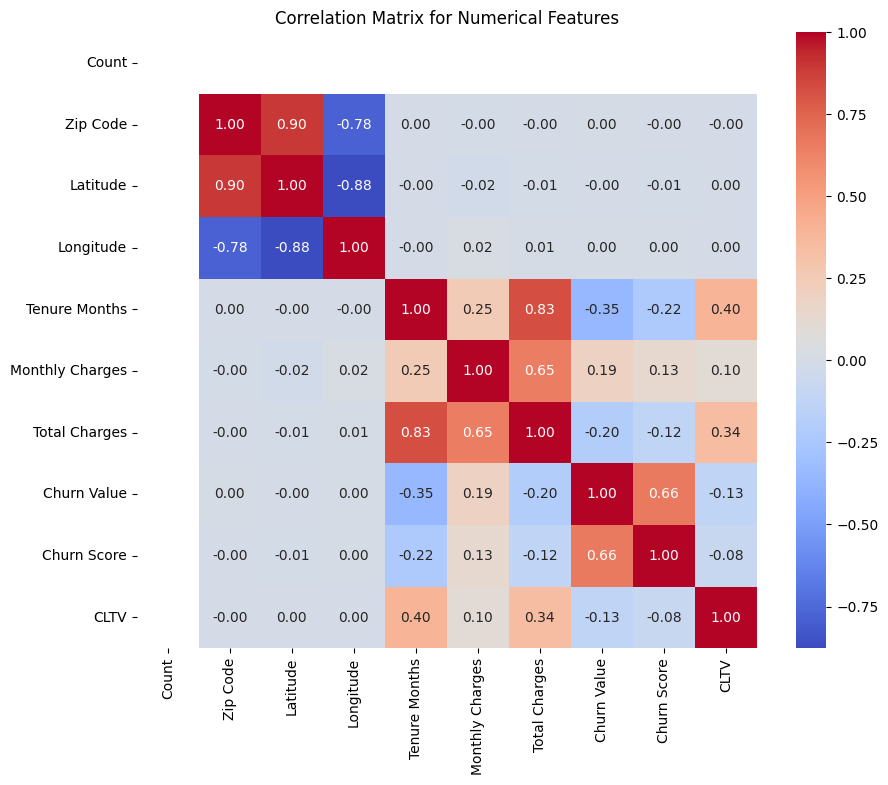

In [80]:
# Correlation matrix for numerical features
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numerical_cols].corr()

# Heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix for Numerical Features')
plt.show()

## Understanding Churn Reason

In [81]:
df['Churn Reason'].value_counts(normalize=True)

Churn Reason
Attitude of support person                   0.102729
Competitor offered higher download speeds    0.101124
Competitor offered more data                 0.086677
Don't know                                   0.082397
Competitor made better offer                 0.074906
Attitude of service provider                 0.072231
Competitor had better devices                0.069556
Network reliability                          0.055110
Product dissatisfaction                      0.054575
Price too high                               0.052434
Service dissatisfaction                      0.047619
Lack of self-service on Website              0.047084
Extra data charges                           0.030498
Moved                                        0.028357
Lack of affordable download/upload speed     0.023542
Limited range of services                    0.023542
Long distance charges                        0.023542
Poor expertise of phone support              0.010701
Poor expertise 

## Dropping columns that won't be used in modeling

In [82]:
drop_cols = [
            'CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
            'Lat Long', 'Latitude', 'Longitude',  # Localização inútil
            'Churn Label',  # Usar Churn Value em vez disso
            'Churn Reason',  # Razão subjetiva
            'CLTV',  # Leakage - correlacionado com churn
            'Churn Score',  # Leakage - score de churn externo
        ]

In [83]:
df = df.drop(columns=drop_cols)

## Target variable distribution

In [84]:
df.rename(columns={'Churn Value': 'Churn'}, inplace=True)

In [85]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

## Onehotencoding the categorical variables

In [86]:
df.columns = [col.lower().strip().replace(' ', '_') for col in df.columns]

In [87]:
# Keeping only alphanumeric characters and underscores in column names
df.columns = df.columns.str.replace(r'[^a-z0-9_]', '', regex=True)

In [88]:
# Check which columns are object type
object_columns = df.select_dtypes(include=['object']).columns.tolist()
print("Object type columns:")
print(object_columns)

# One-hot encoding the categorical variables
df_encoded = pd.get_dummies(df, columns=object_columns, drop_first=True)

print(f"\nOriginal shape: {df.shape}")
print(f"After one-hot encoding: {df_encoded.shape}")
print(f"\nNew columns: {df_encoded.columns.tolist()}")

Object type columns:
['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method']

Original shape: (7043, 20)
After one-hot encoding: (7043, 31)

New columns: ['tenure_months', 'monthly_charges', 'total_charges', 'churn', 'gender_Male', 'senior_citizen_Yes', 'partner_Yes', 'dependents_Yes', 'phone_service_Yes', 'multiple_lines_No phone service', 'multiple_lines_Yes', 'internet_service_Fiber optic', 'internet_service_No', 'online_security_No internet service', 'online_security_Yes', 'online_backup_No internet service', 'online_backup_Yes', 'device_protection_No internet service', 'device_protection_Yes', 'tech_support_No internet service', 'tech_support_Yes', 'streaming_tv_No internet service', 'streaming_tv_Yes', 'streaming_movies_No internet service', 'streaming_movies_Yes', 'cont

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             7043 non-null   object 
 1   senior_citizen     7043 non-null   object 
 2   partner            7043 non-null   object 
 3   dependents         7043 non-null   object 
 4   tenure_months      7043 non-null   int64  
 5   phone_service      7043 non-null   object 
 6   multiple_lines     7043 non-null   object 
 7   internet_service   7043 non-null   object 
 8   online_security    7043 non-null   object 
 9   online_backup      7043 non-null   object 
 10  device_protection  7043 non-null   object 
 11  tech_support       7043 non-null   object 
 12  streaming_tv       7043 non-null   object 
 13  streaming_movies   7043 non-null   object 
 14  contract           7043 non-null   object 
 15  paperless_billing  7043 non-null   object 
 16  payment_method     7043 

In [90]:
df.columns

Index(['gender', 'senior_citizen', 'partner', 'dependents', 'tenure_months',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

In [91]:
numerical_features = ['monthly_charges', 'tenure_months']

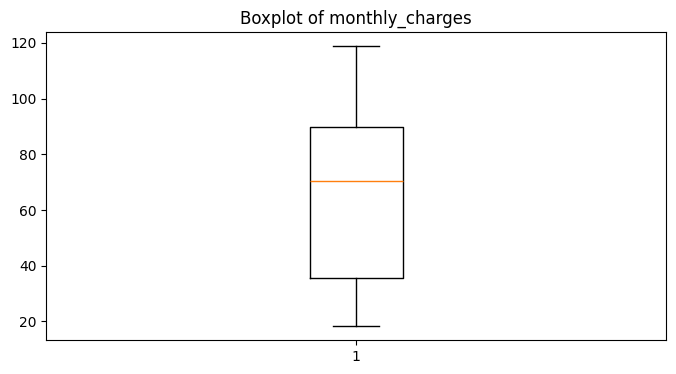

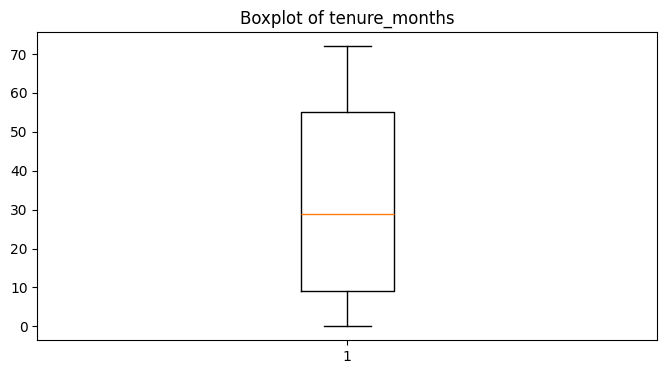

In [92]:
#Checking outliers in the numerical features using boxplots
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df_encoded[feature])
    plt.title(f'Boxplot of {feature}')
    plt.show()

In [93]:
# adding df to mlflow
df_encoded.to_parquet("./processed_data/df_encoded.parquet")
dataset = mlflow.data.from_pandas(df_encoded, source='./processed_data/df_encoded.parquet', name="df_encoded")

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(


In [94]:
## Spliting the data into features and target variable
X = df_encoded.drop('churn', axis=1)

X.columns = [col.replace(' ', '_') for col in X.columns]
# keep only alphanumeric characters and underscores in column names
X.columns = X.columns.str.replace(r'[^a-z0-9_]', '', regex=True)

y = df_encoded['churn']

## Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

In [95]:
# Scaling the numerical features using StandardScaler
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

## Training baseline models

In [ ]:
import numpy as np

def train_model(model, X_train, y_train, X_test, y_test, model_name="Model", scaler=None, cv_folds=5):
    # Start MLflow run
    with mlflow.start_run(run_name=f'Experiment - {model_name}'):

        x_cols = X_train.columns

        # Tranforming into numpy arrays to log in mlflow
        if 'xgboost' in model_name.lower():
            X_train = X_train.values
            y_train = y_train.values
            X_test = X_test.values
            y_test = y_test.values

            train_ds = mlflow.data.from_numpy(X_train, targets=y_train, name="train_data")

            test_ds = mlflow.data.from_numpy(X_test, targets=y_test, name="test_data")
        
        else:
            train_ds = mlflow.data.from_pandas(pd.concat([X_train, y_train], axis=1), 
                                           targets=y_train.name, 
                                           name="train_data")

            test_ds = mlflow.data.from_pandas(pd.concat([X_test, y_test], axis=1), 
                                           targets=y_test.name, 
                                           name="test_data")
    
        # Log model parameters
        params = model.get_params()
        for param_name, param_value in params.items():
            mlflow.log_param(param_name, param_value)

        # Adding datasets
        mlflow.log_input(train_ds, "train_data")
        mlflow.log_input(test_ds, "test_data")
        
        # Train model
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Calculate metrics
        accuracy_train = accuracy_score(y_train, model.predict(X_train))
        precision_train = precision_score(y_train, model.predict(X_train))
        recall_train = recall_score(y_train, model.predict(X_train))
        f1_train = f1_score(y_train, model.predict(X_train))

        accuracy_test = accuracy_score(y_test, y_pred)
        precision_test = precision_score(y_test, y_pred)
        recall_test = recall_score(y_test, y_pred)
        f1_test = f1_score(y_test, y_pred)

        # Log metrics
        mlflow.log_metric("accuracy_train", accuracy_train)
        mlflow.log_metric("precision_train", precision_train)
        mlflow.log_metric("recall_train", recall_train)
        mlflow.log_metric("f1_score_train", f1_train)
        mlflow.log_metric("accuracy_test", accuracy_test)
        mlflow.log_metric("precision_test", precision_test)
        mlflow.log_metric("recall_test", recall_test)
        mlflow.log_metric("f1_score_test", f1_test)

        # AUC-ROC
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        mlflow.log_metric("roc_auc", roc_auc)
        
        # PR-AUC
        precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
        pr_auc = average_precision_score(y_test, y_prob)
        mlflow.log_metric("pr_auc", pr_auc)
        
        # K-Fold Cross-Validation to detect overfitting
        print(f"\n{'='*60}")
        print(f"K-Fold Cross-Validation (k={cv_folds}) Analysis:")
        print(f"{'='*60}")
        
        skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=SEED)
        
        # Define scoring metrics
        scoring = {
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'f1': 'f1',
            'roc_auc': 'roc_auc'
        }
        
        # Prepare data for cross-validation (convert to numpy if needed)
        X_train_cv = X_train.values if isinstance(X_train, pd.DataFrame) else X_train
        y_train_cv = y_train.values if isinstance(y_train, pd.Series) else y_train
        
        # Perform cross-validation
        cv_results = cross_validate(model, X_train_cv, y_train_cv,
                                   cv=skf, scoring=scoring, return_train_score=True)
        
        # Calculate mean and std for each metric
        for metric in scoring.keys():
            train_scores = cv_results[f'train_{metric}']
            test_scores = cv_results[f'test_{metric}']
            
            train_mean = train_scores.mean()
            train_std = train_scores.std()
            test_mean = test_scores.mean()
            test_std = test_scores.std()
            
            # Calculate overfitting indicator (gap between train and test)
            overfitting_gap = train_mean - test_mean
            
            # Log to MLflow
            mlflow.log_metric(f"cv_train_{metric}_mean", train_mean)
            mlflow.log_metric(f"cv_train_{metric}_std", train_std)
            mlflow.log_metric(f"cv_test_{metric}_mean", test_mean)
            mlflow.log_metric(f"cv_test_{metric}_std", test_std)
            mlflow.log_metric(f"cv_{metric}_overfitting_gap", overfitting_gap)
            
            print(f"\n{metric.upper()}:")
            print(f"  Train: {train_mean:.4f} (+/- {train_std:.4f})")
            print(f"  Test:  {test_mean:.4f} (+/- {test_std:.4f})")
            print(f"  Gap:   {overfitting_gap:.4f} (negative = underfitting, positive = overfitting)")
        
        print(f"{'='*60}\n")
        
        # Calculate Churn Cost from False Negatives
        # False Negatives: y_test == 1 (actual churn) and y_pred == 0 (predicted no churn)
        if scaler is not None:
            # Get X_test as DataFrame if it was converted to numpy
            fn_indices = np.where((y_test == 1) & (y_pred == 0))[0]
            fp_indices = np.where((y_test == 0) & (y_pred == 1))[0]
            tp_indices = np.where((y_test == 1) & (y_pred == 1))[0]

            if len(fn_indices) > 0:
                # Get the monthly_charges column index
                monthly_charges_idx = x_cols.get_loc('monthly_charges')
                
                # Extract scaled values for false negatives
                if isinstance(X_test, np.ndarray):
                    scaled_fn_charges = X_test[fn_indices, monthly_charges_idx].reshape(-1, 1)
                else:
                    scaled_fn_charges = X_test.iloc[fn_indices, monthly_charges_idx].values.reshape(-1, 1)
                
                # Create 2-column array (scaler was fitted on 2 features, so we need 2 columns)
                # Second column is zeros since we only care about the first column (monthly_charges)
                scaled_fn_data = np.hstack([scaled_fn_charges, np.zeros((len(fn_indices), 1))])
                
                # Inverse transform to get original values
                unscaled_fn_data = scaler.inverse_transform(scaled_fn_data)
                
                # Sum the monthly charges for false negatives (first column)
                churn_cost = unscaled_fn_data[:, 0].sum()

                # total that can be spent to retain customers that were incorrectly predicted as churned (false positives)
                limit_mkt_cost_tgts = 0
                targets = len(fp_indices) + len(fn_indices) + len(tp_indices)
                if targets > 0:
                    limit_mkt_cost_tgts = churn_cost / targets   # Average cost per false negative

                mlflow.log_metric("false_negatives_count", len(fn_indices))
                mlflow.log_metric("churn_cost_false_negatives", churn_cost)
                mlflow.log_metric("false_positives_count", len(fp_indices))
                mlflow.log_metric("limit_average_marketing_cost_per_target", limit_mkt_cost_tgts if len(targets) > 0 else 0)

                print(f"\nChurn Cost Analysis:")
                print(f"False Negatives: {len(fn_indices)}")
                print(f"True Positives: {len(tp_indices)}")
                print(f"False Positives: {len(fp_indices)}")
                print(f"Churn Cost (sum of monthly charges for FN): ${churn_cost:.2f}")
                
                
                print(f"Limit Average Marketing Cost per False Positive (to match FN cost): ${limit_mkt_cost_fp:.2f}")
            else:
                print("\nNo False Negatives found. Churn cost analysis cannot be performed.")
        
        # Log features and coefficients for Logistic Regression
        if hasattr(model, 'coef_'):
            # Extract feature names and coefficients for numpy arrays
            feature_names = X_train.columns.tolist()
            coefficients = model.coef_[0]
            
            # Log individual feature coefficients and odds ratios
            for feature_name, coef in zip(feature_names, coefficients):
                #mlflow.log_param(f"feature_{feature_name}_coef", round(coef, 6))
                # Odds ratio = exp(coefficient)
                odds_ratio = np.exp(coef)
                #mlflow.log_param(f"feature_{feature_name}_odds_ratio", round(odds_ratio, 6))
            
            # Log intercept
            #mlflow.log_param("intercept", round(model.intercept_[0], 6))
            
            # Create and log a summary artifact with feature importance
            feature_summary = pd.DataFrame({
                'Feature': feature_names,
                'Coefficient': coefficients,
                'Odds_Ratio': np.exp(coefficients)
            }).sort_values('Coefficient', ascending=False)
            
            # Save as CSV artifact
            feature_summary.to_csv('./tmp/feature_coefficients.csv', index=False)
            mlflow.log_artifact('./tmp/feature_coefficients.csv', artifact_path='feature_analysis')
            
            print(f"\nFeature Coefficients and Odds Ratios:")
            print(feature_summary)
        
        # Log model
        mlflow.sklearn.log_model(model, name=model_name)

        # Register model in MLflow Model Registry
        mlflow.register_model(f"runs:/{mlflow.active_run().info.run_id}/{model_name}", model_name)
        
        # Print results
        print(f"\n{model.__class__.__name__} Performance:")
        print(f"Accuracy train: {accuracy_train:.4f}")
        print(f'Accuracy test: {accuracy_test:.4f}')
        
        print(f"Precision train: {precision_train:.4f}")
        print(f"Precision test: {precision_test:.4f}")

        print(f"Recall train: {recall_train:.4f}")
        print(f"Recall test: {recall_test:.4f}")
        
        print(f"F1 Score train: {f1_train:.4f}")
        print(f"F1 Score test: {f1_test:.4f}")
        
        print(f"ROC-AUC: {roc_auc:.4f}")
        print(f"PR-AUC: {pr_auc:.4f}")
        print(classification_report(y_test, y_pred))

        print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

In [163]:
# Training a Dummy Classifier as a baseline model
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=SEED)

train_model(dummy_clf, X_train, y_train, X_test, y_test, model_name="Dummy Classifier", scaler=scaler)

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



K-Fold Cross-Validation (k=5) Analysis:


C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetr


ACCURACY:
  Train: 0.7346 (+/- 0.0000)
  Test:  0.7346 (+/- 0.0001)
  Gap:   0.0000 (negative = underfitting, positive = overfitting)

PRECISION:
  Train: 0.0000 (+/- 0.0000)
  Test:  0.0000 (+/- 0.0000)
  Gap:   0.0000 (negative = underfitting, positive = overfitting)

RECALL:
  Train: 0.0000 (+/- 0.0000)
  Test:  0.0000 (+/- 0.0000)
  Gap:   0.0000 (negative = underfitting, positive = overfitting)

F1:
  Train: 0.0000 (+/- 0.0000)
  Test:  0.0000 (+/- 0.0000)
  Gap:   0.0000 (negative = underfitting, positive = overfitting)

ROC_AUC:
  Train: 0.5000 (+/- 0.0000)
  Test:  0.5000 (+/- 0.0000)
  Gap:   0.0000 (negative = underfitting, positive = overfitting)


Churn Cost Analysis:
False Negatives: 374
True Positives: 0
False Positives: 0
Churn Cost (sum of monthly charges for FN): $27214.90
Limit Average Marketing Cost per False Positive (to match FN cost): $72.77


2026/04/18 13:35:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'Dummy Classifier' already exists. Creating a new version of this model...
2026/04/18 13:36:14 WARNING mlflow.tracking._model_registry.fluent: Run with id 92d9e739b6114cdaa924c81b24c1740b has no artifacts at artifact path 'Dummy Classifier', registering model based on models:/m-d37a9baf604f45b0b30895402d5489ba instead



DummyClassifier Performance:
Accuracy train: 0.7346
Accuracy test: 0.7346
Precision train: 0.0000
Precision test: 0.0000
Recall train: 0.0000
Recall test: 0.0000
F1 Score train: 0.0000
F1 Score test: 0.0000
ROC-AUC: 0.5000
PR-AUC: 0.2654
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409

Confusion Matrix:
[[1035    0]
 [ 374    0]]


Created version '21' of model 'Dummy Classifier'.
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\si

In [164]:
## Training a Logistic Regression model
logreg_clf = LogisticRegression(max_iter=1000, random_state=SEED)

train_model(logreg_clf, X_train, y_train, X_test, y_test, model_name="Logistic Regression", scaler=scaler)


C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



K-Fold Cross-Validation (k=5) Analysis:


C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/mod


ACCURACY:
  Train: 0.8618 (+/- 0.0039)
  Test:  0.7996 (+/- 0.0097)
  Gap:   0.0622 (negative = underfitting, positive = overfitting)

PRECISION:
  Train: 0.7716 (+/- 0.0132)
  Test:  0.6390 (+/- 0.0209)
  Gap:   0.1327 (negative = underfitting, positive = overfitting)

RECALL:
  Train: 0.6811 (+/- 0.0025)
  Test:  0.5639 (+/- 0.0416)
  Gap:   0.1172 (negative = underfitting, positive = overfitting)

F1:
  Train: 0.7235 (+/- 0.0055)
  Test:  0.5983 (+/- 0.0265)
  Gap:   0.1252 (negative = underfitting, positive = overfitting)

ROC_AUC:
  Train: 0.9116 (+/- 0.0051)
  Test:  0.8420 (+/- 0.0118)
  Gap:   0.0696 (negative = underfitting, positive = overfitting)


Churn Cost Analysis:
False Negatives: 161
True Positives: 213
False Positives: 134
Churn Cost (sum of monthly charges for FN): $10716.35
Limit Average Marketing Cost per False Positive (to match FN cost): $21.10

Feature Coefficients and Odds Ratios:
                          Feature  Coefficient  Odds_Ratio
872                  

2026/04/18 13:39:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'Logistic Regression' already exists. Creating a new version of this model...
2026/04/18 13:39:50 WARNING mlflow.tracking._model_registry.fluent: Run with id 912a0204b8034b66ac48302e78a47666 has no artifacts at artifact path 'Logistic Regression', registering model based on models:/m-dcc32d30173a407193f75672f610dd62 instead



LogisticRegression Performance:
Accuracy train: 0.8364
Accuracy test: 0.7906
Precision train: 0.7166
Precision test: 0.6138
Recall train: 0.6341
Recall test: 0.5695
F1 Score train: 0.6728
F1 Score test: 0.5908
ROC-AUC: 0.8398
PR-AUC: 0.6374
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1035
           1       0.61      0.57      0.59       374

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.73      1409
weighted avg       0.79      0.79      0.79      1409

Confusion Matrix:
[[901 134]
 [161 213]]


Created version '16' of model 'Logistic Regression'.


In [165]:
## Training a Logistic Regression model and adding class_weight='balanced' to handle class imbalance
logreg_clf = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')

train_model(logreg_clf, X_train, y_train, X_test, y_test, model_name="Logistic Regression with Class Weight", scaler=scaler)

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



K-Fold Cross-Validation (k=5) Analysis:


C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/mod


ACCURACY:
  Train: 0.7993 (+/- 0.0129)
  Test:  0.7549 (+/- 0.0100)
  Gap:   0.0444 (negative = underfitting, positive = overfitting)

PRECISION:
  Train: 0.5829 (+/- 0.0179)
  Test:  0.5255 (+/- 0.0128)
  Gap:   0.0573 (negative = underfitting, positive = overfitting)

RECALL:
  Train: 0.8595 (+/- 0.0109)
  Test:  0.7846 (+/- 0.0276)
  Gap:   0.0749 (negative = underfitting, positive = overfitting)

F1:
  Train: 0.6946 (+/- 0.0158)
  Test:  0.6294 (+/- 0.0166)
  Gap:   0.0652 (negative = underfitting, positive = overfitting)

ROC_AUC:
  Train: 0.9028 (+/- 0.0096)
  Test:  0.8466 (+/- 0.0131)
  Gap:   0.0562 (negative = underfitting, positive = overfitting)


Churn Cost Analysis:
False Negatives: 78
True Positives: 296
False Positives: 282
Churn Cost (sum of monthly charges for FN): $4903.15
Limit Average Marketing Cost per False Positive (to match FN cost): $7.47

Feature Coefficients and Odds Ratios:
                          Feature  Coefficient  Odds_Ratio
2790  internet_service_i

2026/04/18 13:43:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'Logistic Regression with Class Weight' already exists. Creating a new version of this model...
2026/04/18 13:43:31 WARNING mlflow.tracking._model_registry.fluent: Run with id 57e48b4c7f424ce98467beec5ed12586 has no artifacts at artifact path 'Logistic Regression with Class Weight', registering model based on models:/m-1c31d63aca85435c9207683fe6c520e9 instead



LogisticRegression Performance:
Accuracy train: 0.7813
Accuracy test: 0.7445
Precision train: 0.5576
Precision test: 0.5121
Recall train: 0.8515
Recall test: 0.7914
F1 Score train: 0.6739
F1 Score test: 0.6218
ROC-AUC: 0.8407
PR-AUC: 0.6333
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

Confusion Matrix:
[[753 282]
 [ 78 296]]


Created version '12' of model 'Logistic Regression with Class Weight'.


## Handling Imbalanced Data with SMOTE

In [96]:
smote = SMOTE(random_state=SEED)

# Convert X_train and y_train to float64/int to avoid casting issues with SMOTE
X_train_float = X_train.astype('float64')
y_train_int = y_train.astype('int')

X_train_smote, y_train_smote = smote.fit_resample(X_train_float, y_train_int)

# Convert back to DataFrame with original column names
X_train_smote = pd.DataFrame(X_train_smote, columns=X_train.columns)

In [ ]:
logreg_clf_smote = LogisticRegression(max_iter=1000, random_state=SEED)
train_model(logreg_clf_smote, X_train_smote, y_train_smote, X_test, y_test.astype(int), model_name="Logistic Regression with SMOTE", scaler=scaler)

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



K-Fold Cross-Validation (k=5) Analysis:


C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/mod

KeyboardInterrupt: 

## Adding other models

In [ ]:
# XGBoost Classifier
xgb_clf = XGBClassifier(random_state=SEED, use_label_encoder=False, eval_metric='logloss')
train_model(xgb_clf, X_train, y_train.astype(int), X_test, y_test.astype(int), model_name="XGBoost Classifier", scaler=scaler)

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [13:09:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



K-Fold Cross-Validation (k=5) Analysis:


C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [13:09:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [13:09:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [13:09:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not u


ACCURACY:
  Train: 0.9486 (+/- 0.0057)
  Test:  0.7925 (+/- 0.0078)
  Gap:   0.1561 (negative = underfitting, positive = overfitting)

PRECISION:
  Train: 0.9184 (+/- 0.0112)
  Test:  0.6247 (+/- 0.0187)
  Gap:   0.2937 (negative = underfitting, positive = overfitting)

RECALL:
  Train: 0.8849 (+/- 0.0115)
  Test:  0.5472 (+/- 0.0098)
  Gap:   0.3378 (negative = underfitting, positive = overfitting)

F1:
  Train: 0.9014 (+/- 0.0111)
  Test:  0.5833 (+/- 0.0129)
  Gap:   0.3181 (negative = underfitting, positive = overfitting)

ROC_AUC:
  Train: 0.9878 (+/- 0.0022)
  Test:  0.8448 (+/- 0.0111)
  Gap:   0.1431 (negative = underfitting, positive = overfitting)


Churn Cost Analysis:
False Negatives: 174
True Positives: 200
False Positives: 127
Churn Cost (sum of monthly charges for FN): $11926.10
Limit Average Marketing Cost per False Positive (to match FN cost): $23.80


2026/04/18 13:09:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'XGBoost Classifier' already exists. Creating a new version of this model...
2026/04/18 13:10:10 WARNING mlflow.tracking._model_registry.fluent: Run with id c4e1c78c111b4778a60fd1075afa5dc6 has no artifacts at artifact path 'XGBoost Classifier', registering model based on models:/m-8f9a29c6ca1d4722a4869ec6476e1175 instead



XGBClassifier Performance:
Accuracy train: 0.9162
Accuracy test: 0.7864
Precision train: 0.8720
Precision test: 0.6116
Recall train: 0.8020
Recall test: 0.5348
F1 Score train: 0.8355
F1 Score test: 0.5706
ROC-AUC: 0.8388
PR-AUC: 0.6347
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.61      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.71      1409
weighted avg       0.78      0.79      0.78      1409

Confusion Matrix:
[[908 127]
 [174 200]]


Created version '9' of model 'XGBoost Classifier'.


In [ ]:
# Random Forest Classifier
rf_clf = RandomForestClassifier(random_state=SEED)
train_model(rf_clf, X_train, y_train.astype(int), X_test, y_test.astype(int), model_name="Random Forest Classifier", scaler=scaler)


K-Fold Cross-Validation (k=5) Analysis:

ACCURACY:
  Train: 1.0000 (+/- 0.0000)
  Test:  0.8046 (+/- 0.0085)
  Gap:   0.1954 (negative = underfitting, positive = overfitting)

PRECISION:
  Train: 1.0000 (+/- 0.0000)
  Test:  0.6946 (+/- 0.0279)
  Gap:   0.3054 (negative = underfitting, positive = overfitting)

RECALL:
  Train: 1.0000 (+/- 0.0000)
  Test:  0.4722 (+/- 0.0275)
  Gap:   0.5278 (negative = underfitting, positive = overfitting)

F1:
  Train: 1.0000 (+/- 0.0000)
  Test:  0.5616 (+/- 0.0218)
  Gap:   0.4384 (negative = underfitting, positive = overfitting)

ROC_AUC:
  Train: 1.0000 (+/- 0.0000)
  Test:  0.8473 (+/- 0.0093)
  Gap:   0.1527 (negative = underfitting, positive = overfitting)


Churn Cost Analysis:
False Negatives: 201
True Positives: 173
False Positives: 89
Churn Cost (sum of monthly charges for FN): $13566.95
Limit Average Marketing Cost per False Positive (to match FN cost): $29.30


2026/04/18 13:11:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'Random Forest Classifier' already exists. Creating a new version of this model...
2026/04/18 13:11:44 WARNING mlflow.tracking._model_registry.fluent: Run with id ddd9d8a895e64ba79162f0e59c0b63d0 has no artifacts at artifact path 'Random Forest Classifier', registering model based on models:/m-0f91ca4a80a44ee9b881af395d1bb4e2 instead



RandomForestClassifier Performance:
Accuracy train: 1.0000
Accuracy test: 0.7942
Precision train: 1.0000
Precision test: 0.6603
Recall train: 1.0000
Recall test: 0.4626
F1 Score train: 1.0000
F1 Score test: 0.5440
ROC-AUC: 0.8390
PR-AUC: 0.6484
              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1035
           1       0.66      0.46      0.54       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

Confusion Matrix:
[[946  89]
 [201 173]]


Created version '8' of model 'Random Forest Classifier'.


In [ ]:
# Random Search CV for Hyperparameter Tuning of XGBoost

random_search_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_clf_random = XGBClassifier(random_state=SEED, use_label_encoder=False, eval_metric='logloss')
random_search = RandomizedSearchCV(estimator=xgb_clf_random, param_distributions=random_search_params, n_iter=10, cv=3, verbose=2, random_state=SEED, n_jobs=-1)

random_search.fit(X_train.values, y_train.astype(int))

print(f"Best parameters found: {random_search.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [13:14:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters found: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [ ]:
# Using the best estimator from random search to train and evaluate
best_xgb_clf = random_search.best_estimator_
train_model(best_xgb_clf, X_train, y_train.astype(int), X_test, y_test.astype(int), model_name="XGBoost Classifier with Random Search CV", scaler=scaler)

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [13:15:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



K-Fold Cross-Validation (k=5) Analysis:


C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [13:15:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [13:15:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [13:15:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not u


ACCURACY:
  Train: 0.8335 (+/- 0.0024)
  Test:  0.8104 (+/- 0.0109)
  Gap:   0.0230 (negative = underfitting, positive = overfitting)

PRECISION:
  Train: 0.7389 (+/- 0.0060)
  Test:  0.6848 (+/- 0.0311)
  Gap:   0.0541 (negative = underfitting, positive = overfitting)

RECALL:
  Train: 0.5761 (+/- 0.0154)
  Test:  0.5311 (+/- 0.0164)
  Gap:   0.0450 (negative = underfitting, positive = overfitting)

F1:
  Train: 0.6473 (+/- 0.0088)
  Test:  0.5980 (+/- 0.0196)
  Gap:   0.0492 (negative = underfitting, positive = overfitting)

ROC_AUC:
  Train: 0.9009 (+/- 0.0014)
  Test:  0.8666 (+/- 0.0108)
  Gap:   0.0343 (negative = underfitting, positive = overfitting)


Churn Cost Analysis:
False Negatives: 171
True Positives: 203
False Positives: 95
Churn Cost (sum of monthly charges for FN): $11335.35
Limit Average Marketing Cost per False Positive (to match FN cost): $24.17


2026/04/18 13:16:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'XGBoost Classifier with Random Search CV' already exists. Creating a new version of this model...
2026/04/18 13:16:45 WARNING mlflow.tracking._model_registry.fluent: Run with id a6dd2e2aed8d4ec796b737569579f403 has no artifacts at artifact path 'XGBoost Classifier with Random Search CV', registering model based on models:/m-9daca268940b4743906baf85d8e8bde6 instead



XGBClassifier Performance:
Accuracy train: 0.8296
Accuracy test: 0.8112
Precision train: 0.7340
Precision test: 0.6812
Recall train: 0.5612
Recall test: 0.5428
F1 Score train: 0.6361
F1 Score test: 0.6042
ROC-AUC: 0.8582
PR-AUC: 0.6731
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1035
           1       0.68      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Confusion Matrix:
[[940  95]
 [171 203]]


Created version '9' of model 'XGBoost Classifier with Random Search CV'.


In [ ]:
# Random search for Random Forest Classifier
rf_random_search_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf_clf_random = RandomForestClassifier(random_state=SEED)
rf_random_search = RandomizedSearchCV(estimator=rf_clf_random, param_distributions=rf_random_search_params, n_iter=10, cv=3, verbose=2, random_state=SEED, n_jobs=-1)

rf_random_search.fit(X_train, y_train.astype(int))
print(f"Best parameters found for Random Forest: {rf_random_search.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters found for Random Forest: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'bootstrap': True}


In [ ]:
# Training a Random Forest Classifier with best parameters from random search
best_rf_clf = rf_random_search.best_estimator_
train_model(best_rf_clf, X_train, y_train.astype(int), X_test, y_test.astype(int), model_name="Random Forest Classifier with Random Search CV", scaler=scaler)



K-Fold Cross-Validation (k=5) Analysis:

ACCURACY:
  Train: 0.8254 (+/- 0.0034)
  Test:  0.7819 (+/- 0.0064)
  Gap:   0.0435 (negative = underfitting, positive = overfitting)

PRECISION:
  Train: 0.8703 (+/- 0.0090)
  Test:  0.7391 (+/- 0.0346)
  Gap:   0.1312 (negative = underfitting, positive = overfitting)

RECALL:
  Train: 0.4018 (+/- 0.0110)
  Test:  0.2756 (+/- 0.0159)
  Gap:   0.1263 (negative = underfitting, positive = overfitting)

F1:
  Train: 0.5497 (+/- 0.0116)
  Test:  0.4012 (+/- 0.0199)
  Gap:   0.1485 (negative = underfitting, positive = overfitting)

ROC_AUC:
  Train: 0.9380 (+/- 0.0021)
  Test:  0.8433 (+/- 0.0114)
  Gap:   0.0947 (negative = underfitting, positive = overfitting)


Churn Cost Analysis:
False Negatives: 271
True Positives: 103
False Positives: 34
Churn Cost (sum of monthly charges for FN): $18998.75
Limit Average Marketing Cost per False Positive (to match FN cost): $46.57


2026/04/18 13:18:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'Random Forest Classifier with Random Search CV' already exists. Creating a new version of this model...
2026/04/18 13:18:53 WARNING mlflow.tracking._model_registry.fluent: Run with id b3a52a895f2e4c948e599c0a0246dad5 has no artifacts at artifact path 'Random Forest Classifier with Random Search CV', registering model based on models:/m-eb31711cb54246daae04ddfae97a1087 instead



RandomForestClassifier Performance:
Accuracy train: 0.8220
Accuracy test: 0.7835
Precision train: 0.8596
Precision test: 0.7518
Recall train: 0.3933
Recall test: 0.2754
F1 Score train: 0.5397
F1 Score test: 0.4031
ROC-AUC: 0.8338
PR-AUC: 0.6382
              precision    recall  f1-score   support

           0       0.79      0.97      0.87      1035
           1       0.75      0.28      0.40       374

    accuracy                           0.78      1409
   macro avg       0.77      0.62      0.64      1409
weighted avg       0.78      0.78      0.74      1409

Confusion Matrix:
[[1001   34]
 [ 271  103]]


Created version '8' of model 'Random Forest Classifier with Random Search CV'.


## Creating Neural Network with PyTorch

In [97]:


from pyexpat import model


def train_and_evaluate_nn(X_train, y_train, X_test, y_test, model_name="Neural Network", 
                          num_epochs=100, patience=10, min_delta=0.0001, val_split=0.2,
                          learning_rate=0.001, batch_size=32, log_to_mlflow=True, 
                          NN=None, scaler=None):
    """
    Train and evaluate a neural network with logit-based loss and proper probability conversion.
    """
    from torch.utils.data import DataLoader, TensorDataset
    
    if NN is None:
        raise ValueError("Please provide a Neural Network class (e.g., ChurnNetWOSig)")

    # Store column names for cost analysis
    x_test_cols = X_test.columns
    
    # Ensure data is float32
    X_train = X_train.astype('float32')
    X_test = X_test.astype('float32')
    
    # Create validation split
    val_size = int(len(X_train) * val_split)
    X_train_split = X_train.iloc[:-val_size]
    X_val_split = X_train.iloc[-val_size:]
    y_train_split = y_train.iloc[:-val_size]
    y_val_split = y_train.iloc[-val_size:]
    
    # Convert to tensors
    X_train_tensor = torch.tensor(X_train_split.values, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_split.values, dtype=torch.float32).view(-1, 1)
    X_val_tensor = torch.tensor(X_val_split.values, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val_split.values, dtype=torch.float32).view(-1, 1)
    X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

    # DataLoaders
    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)

    # Start MLflow Run
    run_context = mlflow.start_run(run_name=f'Experiment - {model_name}') if log_to_mlflow else nullcontext()
    
    with run_context:
        # Dynamic pos_weight calculation for imbalance
        num_pos = torch.sum(y_train_tensor == 1).float()
        num_neg = torch.sum(y_train_tensor == 0).float()
        pos_weight = torch.tensor([num_neg / (num_pos + 1e-8)])

        # BCEWithLogitsLoss expects raw logits from the model
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        
        input_dim = X_train.shape[1]
        model = NN(input_dim)
        # Equivalent to L2 regularization
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        
        best_val_loss = float('inf')
        patience_counter = 0
        best_model_state = None
        epochs_trained = 0
        
        # --- Training Loop ---
        for epoch in range(num_epochs):
            model.train()
            epoch_train_loss = 0.0
            for X_batch, y_batch in train_loader:
                optimizer.zero_grad()
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                loss.backward()
                optimizer.step()
                epoch_train_loss += loss.item()
            
            # --- Validation ---
            model.eval()
            epoch_val_loss = 0.0
            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    val_logits = model(X_batch)
                    val_loss = criterion(val_logits, y_batch)
                    epoch_val_loss += val_loss.item()
            
            avg_train_loss = epoch_train_loss / len(train_loader)
            avg_val_loss = epoch_val_loss / len(val_loader)
            epochs_trained = epoch + 1

            # Early stopping
            if avg_val_loss < best_val_loss - min_delta:
                best_val_loss = avg_val_loss
                patience_counter = 0
                best_model_state = model.state_dict().copy()
            else:
                patience_counter += 1
            
            if (epoch+1) % 5 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')
            
            if patience_counter >= patience:
                print(f'\nEarly stopping at epoch {epoch+1}. Best Val Loss: {best_val_loss:.4f}')
                model.load_state_dict(best_model_state)
                break

        # --- Evaluation ---
        model.eval()
        y_pred_prob_list = []
        with torch.no_grad():
            for X_batch, _ in test_loader:
                logits = model(X_batch)
                # Convert logits to probabilities via Sigmoid
                probs = torch.sigmoid(logits).cpu().numpy()
                y_pred_prob_list.append(probs)
        
        y_pred_prob = np.vstack(y_pred_prob_list).flatten()
        y_pred = (y_pred_prob > 0.5).astype(int)
        
        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        pr_auc = average_precision_score(y_test, y_pred_prob)
        
        # Churn Cost Analysis
        if scaler is not None:
            fn_indices = np.where((y_test.values.flatten() == 1) & (y_pred == 0))[0]
            fp_indices = np.where((y_test.values.flatten() == 0) & (y_pred == 1))[0]
            
            if len(fn_indices) > 0:
                monthly_charges_idx = x_test_cols.get_loc('monthly_charges')
                scaled_fn_charges = X_test.iloc[fn_indices, monthly_charges_idx].values.reshape(-1, 1)
                # Dummy array for inverse transform (assumes scaler expects 2 features)
                dummy_data = np.hstack([scaled_fn_charges, np.zeros((len(fn_indices), 1))])
                unscaled_data = scaler.inverse_transform(dummy_data)
                churn_cost = unscaled_data[:, 0].sum()
                
                print(f"\nChurn Cost Analysis:")
                print(f"False Negatives: {len(fn_indices)} | Cost: ${churn_cost:.2f}")
                print(f"False Positives: {len(fp_indices)}")

        print(f'\n{model_name} Results:')
        print(f'Accuracy: {accuracy:.4f} | Recall: {recall:.4f} | ROC-AUC: {roc_auc:.4f}')

        if log_to_mlflow:
            mlflow.log_params({"lr": learning_rate, "batch_size": batch_size, "patience": patience})
            mlflow.log_metrics({"accuracy": accuracy, "recall": recall, "roc_auc": roc_auc, "f1": f1})
            mlflow.pytorch.log_model(model, "model")

    return {'model': model, 'accuracy': accuracy, 'recall': recall, 'roc_auc': roc_auc, 'y_pred_prob': y_pred_prob}

In [98]:
class SimpleChurnNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleChurnNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.output = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.output(x)
        x = self.sigmoid(x)
        return x

In [99]:
# Train the neural network
nn_results = train_and_evaluate_nn(X_train_smote, y_train_smote, X_test, y_test, 
                                    model_name="Neural Network with SMOTE", NN=SimpleChurnNN, scaler=scaler)


Epoch [5/100], Train Loss: 0.8098, Val Loss: 0.9996
Epoch [10/100], Train Loss: 0.8283, Val Loss: 0.8566
Epoch [15/100], Train Loss: 0.7889, Val Loss: 0.7547
Epoch [20/100], Train Loss: 0.8111, Val Loss: 0.8855
Epoch [25/100], Train Loss: 0.7840, Val Loss: 0.8529
Epoch [30/100], Train Loss: 0.7843, Val Loss: 0.6962


2026/04/22 23:09:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Early stopping at epoch 33. Best Val Loss: 0.5533

Churn Cost Analysis:
False Negatives: 75 | Cost: $6618.70
False Positives: 376

Neural Network with SMOTE Results:
Accuracy: 0.6799 | Recall: 0.7995 | ROC-AUC: 0.7865


2026/04/22 23:09:28 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


In [100]:
class LogisticRegressionNN(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegressionNN, self).__init__()
        # One linear layer: input_dim -> 1 output
        self.linear = nn.Linear(input_dim, 1)
        
    def forward(self, x):
        # Sigmoid squashes the output between 0 and 1 (probability)
        return torch.sigmoid(self.linear(x))

In [101]:
nn_results_logreg = train_and_evaluate_nn(X_train_smote, y_train_smote, X_test, y_test,
                                         model_name="Logistic Regression NN with SMOTE", NN=LogisticRegressionNN, scaler=scaler)

Epoch [5/100], Train Loss: 0.7908, Val Loss: 0.8590
Epoch [10/100], Train Loss: 0.7862, Val Loss: 0.8377


2026/04/22 23:09:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Early stopping at epoch 11. Best Val Loss: 0.5242

Churn Cost Analysis:
False Negatives: 44 | Cost: $4327.65
False Positives: 689

Logistic Regression NN with SMOTE Results:
Accuracy: 0.4798 | Recall: 0.8824 | ROC-AUC: 0.7672


2026/04/22 23:09:44 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


In [102]:
nn_results_logreg = train_and_evaluate_nn(X_train, y_train, X_test, y_test,
                                         model_name="Logistic Regression NN", NN=LogisticRegressionNN, scaler=scaler)

Epoch [5/100], Train Loss: 1.0995, Val Loss: 0.9677
Epoch [10/100], Train Loss: 0.9226, Val Loss: 0.9318
Epoch [15/100], Train Loss: 0.9312, Val Loss: 0.9267
Epoch [20/100], Train Loss: 0.9147, Val Loss: 0.9269
Epoch [25/100], Train Loss: 0.9128, Val Loss: 0.9312
Epoch [30/100], Train Loss: 0.9064, Val Loss: 0.9316
Epoch [35/100], Train Loss: 0.9051, Val Loss: 0.9266
Epoch [40/100], Train Loss: 0.9055, Val Loss: 0.9194
Epoch [45/100], Train Loss: 0.9071, Val Loss: 0.9170
Epoch [50/100], Train Loss: 0.9092, Val Loss: 0.9301
Epoch [55/100], Train Loss: 0.9166, Val Loss: 0.9170
Epoch [60/100], Train Loss: 0.9036, Val Loss: 0.9282
Epoch [65/100], Train Loss: 0.9013, Val Loss: 0.9245


2026/04/22 23:10:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Early stopping at epoch 68. Best Val Loss: 0.9160

Churn Cost Analysis:
False Negatives: 18 | Cost: $1853.05
False Positives: 755

Logistic Regression NN Results:
Accuracy: 0.4514 | Recall: 0.9519 | ROC-AUC: 0.8187


2026/04/22 23:10:18 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


In [103]:

class ChurnNet(nn.Module):
    def __init__(self, input_dim):
        super(ChurnNet, self).__init__()
        # Increasing capacity slightly
        self.l1 = nn.Linear(input_dim, 16)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2) # Prevents overfitting
        self.l2 = nn.Linear(16, 8)
        self.l3 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.dropout(x)
        x = self.relu(self.l2(x))
        return self.sigmoid(self.l3(x))

In [104]:
nn_results_churnnet = train_and_evaluate_nn(X_train_smote, y_train_smote, X_test, y_test,
                                         model_name="ChurnNet with SMOTE", NN=ChurnNet, scaler=scaler)

Epoch [5/100], Train Loss: 0.8351, Val Loss: 0.9919
Epoch [10/100], Train Loss: 0.7914, Val Loss: 0.8311
Epoch [15/100], Train Loss: 0.7855, Val Loss: 0.8484
Epoch [20/100], Train Loss: 0.7824, Val Loss: 0.7402
Epoch [25/100], Train Loss: 0.7789, Val Loss: 0.7885


2026/04/22 23:10:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Early stopping at epoch 27. Best Val Loss: 0.6933

Churn Cost Analysis:
False Negatives: 15 | Cost: $1527.90
False Positives: 733

ChurnNet with SMOTE Results:
Accuracy: 0.4691 | Recall: 0.9599 | ROC-AUC: 0.8226


2026/04/22 23:10:56 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


In [105]:
class ChurnNetWOSig(nn.Module):
    def __init__(self, input_dim):
        super(ChurnNetWOSig, self).__init__()
        # Wider first layer to capture more feature interactions
        self.l1 = nn.Linear(input_dim, 16)
        # Using LeakyReLU to prevent "dead" neurons in small networks
        self.relu = nn.LeakyReLU(0.01) 
        self.dropout = nn.Dropout(0.2) 
        self.l2 = nn.Linear(16, 8)
        self.l3 = nn.Linear(8, 1)
        # NO SIGMOID HERE - We use BCEWithLogitsLoss for stability
        
    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.dropout(x)
        x = self.relu(self.l2(x))
        # Returns raw logits (-inf to +inf)
        return self.l3(x)

In [106]:
nn_results_churnnet = train_and_evaluate_nn(X_train_smote, y_train_smote, X_test, y_test,
                                         model_name="ChurnNet with SMOTE", NN=ChurnNet, scaler=scaler)

Epoch [5/100], Train Loss: 0.8585, Val Loss: 0.9870
Epoch [10/100], Train Loss: 0.8028, Val Loss: 0.8455


2026/04/22 23:11:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Early stopping at epoch 13. Best Val Loss: 0.6201

Churn Cost Analysis:
False Negatives: 35 | Cost: $3503.55
False Positives: 735

ChurnNet with SMOTE Results:
Accuracy: 0.4535 | Recall: 0.9064 | ROC-AUC: 0.7736


2026/04/22 23:11:23 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


In [107]:
nn_results_churnnet = train_and_evaluate_nn(X_train, y_train, X_test, y_test,
                                         model_name="ChurnNet", NN=ChurnNet, scaler=scaler)

Epoch [5/100], Train Loss: 0.9747, Val Loss: 0.9725
Epoch [10/100], Train Loss: 0.9387, Val Loss: 0.9537
Epoch [15/100], Train Loss: 0.9206, Val Loss: 0.9296
Epoch [20/100], Train Loss: 0.9299, Val Loss: 0.9349
Epoch [25/100], Train Loss: 0.9384, Val Loss: 0.9443
Epoch [30/100], Train Loss: 0.9206, Val Loss: 0.9246
Epoch [35/100], Train Loss: 0.9198, Val Loss: 0.9297
Epoch [40/100], Train Loss: 0.9209, Val Loss: 0.9371


2026/04/22 23:11:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Early stopping at epoch 41. Best Val Loss: 0.9213

Churn Cost Analysis:
False Negatives: 94 | Cost: $7986.60
False Positives: 311

ChurnNet Results:
Accuracy: 0.7126 | Recall: 0.7487 | ROC-AUC: 0.7714


2026/04/22 23:12:00 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


In [ ]:
import torch.nn.functional as F

class GatedLinearUnit(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.fc = nn.Linear(input_dim, output_dim * 2) # Double size for gating

    def forward(self, x):
        x = self.fc(x)
        # Split in half: one for values, one for the gate
        x, gate = torch.split(x, x.shape[-1] // 2, dim=-1)
        return x * torch.sigmoid(gate)
    
class FeatureTransformer(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.glu = GatedLinearUnit(input_dim, output_dim)
        self.scale = torch.sqrt(torch.tensor([0.5])) # Scaler for residual connection

    def forward(self, x):
        # Simplest version: GLU + Residual Connection
        x_out = self.glu(x)
        return (x + x_out) * self.scale if x.shape == x_out.shape else x_out

class AttentiveTransformer(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.fc = nn.Linear(input_dim, output_dim)
        self.bn = nn.BatchNorm1d(output_dim)
        # Sparsemax isn't built into PyTorch, but can be imported or simplified
        # For this example, we'll assume a Sparsemax logic

    def forward(self, x, prior_scales):
        x = self.bn(self.fc(x))
        x = x * prior_scales # Don't look at what we already used too much
        # return sparsemax(x)
        return F.softmax(x, dim=-1) # Placeholder for Sparsemax

class AttentiveTransformer(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.fc = nn.Linear(input_dim, output_dim)
        self.bn = nn.BatchNorm1d(output_dim)
        # Sparsemax isn't built into PyTorch, but can be imported or simplified
        # For this example, we'll assume a Sparsemax logic

    def forward(self, x, prior_scales):
        x = self.bn(self.fc(x))
        x = x * prior_scales # Don't look at what we already used too much
        # return sparsemax(x)
        return F.softmax(x, dim=-1) # Placeholder for Sparsemax


class TabNetSimplified(nn.Module):
    def __init__(self, input_dim, output_dim, n_steps=3):
        super().__init__()
        self.n_steps = n_steps
        self.input_dim = input_dim
        
        # Transformers
        self.feature_transformer = FeatureTransformer(input_dim, 16)
        self.attentive_transformer = AttentiveTransformer(16, input_dim)
        
        self.final_mapping = nn.Linear(16, output_dim)

    def forward(self, x):
        batch_size = x.shape[0]
        prior_scales = torch.ones((batch_size, self.input_dim))
        out_accumulator = 0
        
        # Step 0: Initial processing
        x_processed = self.feature_transformer(x)
        
        for step in range(self.n_steps):
            # 1. Decide which features to look at
            mask = self.attentive_transformer(x_processed, prior_scales)
            
            # 2. Apply mask to raw features
            masked_x = x * mask
            
            # 3. Process the masked features
            step_output = self.feature_transformer(masked_x)
            
            # 4. Accumulate results
            out_accumulator += F.relu(step_output)
            
            # 5. Update priors (so we look at NEW things in the next step)
            prior_scales = prior_scales * (1.5 - mask) # Simple relaxation logic
            x_processed = step_output
            
        return self.final_mapping(out_accumulator)

In [ ]:

def train_and_evaluate_tabnet(X_train, y_train, X_test, y_test, model_name="TabNet_Churn", 
                              num_epochs=100, patience=15, learning_rate=0.02, 
                              batch_size=128, n_steps=3, log_to_mlflow=True, 
                              NN=None, scaler=None):
    """
    Specialized training function for TabNet architecture with sequential attention.
    """
    from torch.utils.data import DataLoader, TensorDataset
    
    # Device configuration (Uses your NVIDIA RTX 2000)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Column names for cost analysis
    x_test_cols = X_test.columns
    
    # Pre-process data
    X_train_f32 = X_train.astype('float32')
    X_test_f32 = X_test.astype('float32')
    
    # Tensors and DataLoaders
    X_train_tensor = torch.tensor(X_train_f32.values).to(device)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)
    X_test_tensor = torch.tensor(X_test_f32.values).to(device)
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1).to(device)

    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)

    # Calculate pos_weight for imbalance
    num_pos = torch.sum(y_train_tensor == 1).float()
    num_neg = torch.sum(y_train_tensor == 0).float()
    pos_weight = (num_neg / (num_pos + 1e-8)).to(device)
    print(pos_weight)

    # Initialize model
    input_dim = X_train.shape[1]
    model = NN(input_dim=input_dim, output_dim=1, n_steps=n_steps).to(device)
    
    # TabNet often performs better with Adam and a slightly higher learning rate
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_loss = float('inf')
    patience_counter = 0
    epochs_trained = 0

    print(f"Starting TabNet Training...")

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            
            # Prevent exploding gradients in attention blocks
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        epochs_trained += 1

        # Early Stopping logic based on Training Loss (simplified)
        if avg_loss < best_loss:
            best_loss = avg_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            model.load_state_dict(best_model_state)
            break

    # --- Evaluation ---
    model.eval()
    with torch.no_grad():
        test_logits = model(X_test_tensor)
        y_pred_prob = torch.sigmoid(test_logits).cpu().numpy().flatten()
        y_pred = (y_pred_prob > 0.5).astype(int)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, zero_division=0)
    precision = precision_score(y_test, y_pred, zero_division=0)
    roc_auc = auc(*roc_curve(y_test, y_pred_prob)[0:2])

    print(f"\n--- {model_name} Final Performance ---")
    print(f"Accuracy: {accuracy:.4f} | Recall: {recall:.4f} | ROC-AUC: {roc_auc:.4f}")

    # Log to MLflow
    if log_to_mlflow:
        with mlflow.start_run(run_name=model_name):
            mlflow.log_params({"lr": learning_rate, "n_steps": n_steps, "batch_size": batch_size})
            mlflow.log_metrics({"accuracy": accuracy, "recall": recall, "roc_auc": roc_auc})
            mlflow.pytorch.log_model(model, "tabnet_model")

    return {
        'model': model,
        'y_pred': y_pred,
        'y_pred_prob': y_pred_prob,
        'auc': roc_auc
    }

In [ ]:
# Assuming X_train_scaled, y_train, etc. are ready
results = train_and_evaluate_tabnet(
    X_train, y_train, 
    X_test, y_test, 
    NN=TabNetSimplified, # The class you built
    n_steps=5,           # Number of sequential decision steps
    learning_rate=0.01,
    scaler=scaler
)

Using device: cpu
tensor(2.7686)
Starting TabNet Training...
Epoch [10/100] | Loss: 0.6917
Epoch [20/100] | Loss: 0.6625
Epoch [30/100] | Loss: 0.6382
Epoch [40/100] | Loss: 0.6230
Epoch [50/100] | Loss: 0.5909
Epoch [60/100] | Loss: 0.5092
Epoch [70/100] | Loss: 0.4596
Epoch [80/100] | Loss: 0.4088
Epoch [90/100] | Loss: 0.3695
Epoch [100/100] | Loss: 0.3378


2026/04/18 13:25:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



--- TabNet_Churn Final Performance ---
Accuracy: 0.7317 | Recall: 0.0027 | ROC-AUC: 0.6292


2026/04/18 13:25:26 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


In [40]:
# Classe MLP
class MLPClassifier(nn.Module):
    """
    Multi-Layer Perceptron para classificação binária
    Arquitetura: Input -> Hidden(128, ReLU) -> Hidden(64, ReLU) -> Hidden(32, ReLU) -> Output(1, Logits)
    """
    def __init__(self, input_size, hidden_sizes=[128, 64, 32], dropout_rates=[0.3, 0.2, 0.0]):
        super(MLPClassifier, self).__init__()
        
        layers = []
        prev_size = input_size
        
        # Hidden layers com dropout
        for i, hidden_size in enumerate(hidden_sizes):
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            if dropout_rates[i] > 0:
                layers.append(nn.Dropout(dropout_rates[i]))
            prev_size = hidden_size
        
        # Output layer (logits)
        layers.append(nn.Linear(prev_size, 1))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

In [66]:
nn_results_churnnet = train_and_evaluate_nn(X_train, y_train, X_test, y_test,
                                         model_name="MLPClassifier", NN=MLPClassifier, scaler=scaler)

Epoch [5/100], Train Loss: 1.0360, Val Loss: 0.9876
Epoch [10/100], Train Loss: 0.9856, Val Loss: 0.9863
Epoch [15/100], Train Loss: 0.9889, Val Loss: 0.9854
Epoch [20/100], Train Loss: 0.9710, Val Loss: 0.9741
Epoch [25/100], Train Loss: 0.9266, Val Loss: 0.9250
Epoch [30/100], Train Loss: 0.8605, Val Loss: 0.8459
Epoch [35/100], Train Loss: 0.8055, Val Loss: 0.8199
Epoch [40/100], Train Loss: 0.7665, Val Loss: 0.7769
Epoch [45/100], Train Loss: 0.7679, Val Loss: 0.7772
Epoch [50/100], Train Loss: 0.7519, Val Loss: 0.7575
Epoch [55/100], Train Loss: 0.7356, Val Loss: 0.7452
Epoch [60/100], Train Loss: 0.7471, Val Loss: 0.8251


2026/04/22 23:08:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch [65/100], Train Loss: 0.7217, Val Loss: 0.7487

Early stopping at epoch 65. Best Val Loss: 0.7452

Churn Cost Analysis:
False Negatives: 66 | Cost: $4114.05
False Positives: 328

MLPClassifier Results:
Accuracy: 0.7204 | Recall: 0.8235 | ROC-AUC: 0.8448


2026/04/22 23:08:10 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


In [42]:
nn_results_churnnet = train_and_evaluate_nn(X_train_smote, y_train_smote, X_test, y_test,
                                         model_name="MLPClassifier SMOTE", NN=MLPClassifier, scaler=scaler)

Epoch [5/100], Train Loss: 0.8666, Val Loss: 1.1578
Epoch [10/100], Train Loss: 0.8666, Val Loss: 1.1625


2026/04/22 22:48:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Early stopping at epoch 12. Best Val Loss: 1.1449

Churn Cost Analysis:
False Negatives: 371 | Cost: $27154.50
False Positives: 9

MLPClassifier SMOTE Results:
Accuracy: 0.7303 | Recall: 0.0080 | ROC-AUC: 0.5011


2026/04/22 22:48:46 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


In [64]:

train_and_evaluate_nn(X_train_smote, y_train_smote, X_test, y_test,
                      model_name="MLPClassifier with SMOTE", NN=MLPClassifier, scaler=scaler)

Epoch [5/100], Train Loss: 0.8660, Val Loss: 1.1492
Epoch [10/100], Train Loss: 0.8659, Val Loss: 1.1553


2026/04/22 23:05:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Early stopping at epoch 11. Best Val Loss: 1.1400

Churn Cost Analysis:
False Negatives: 361 | Cost: $26940.60
False Positives: 22

MLPClassifier with SMOTE Results:
Accuracy: 0.7282 | Recall: 0.0348 | ROC-AUC: 0.5142


2026/04/22 23:05:53 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


{'model': MLPClassifier(
   (network): Sequential(
     (0): Linear(in_features=30, out_features=128, bias=True)
     (1): ReLU()
     (2): Dropout(p=0.3, inplace=False)
     (3): Linear(in_features=128, out_features=64, bias=True)
     (4): ReLU()
     (5): Dropout(p=0.2, inplace=False)
     (6): Linear(in_features=64, out_features=32, bias=True)
     (7): ReLU()
     (8): Linear(in_features=32, out_features=1, bias=True)
   )
 ),
 'accuracy': 0.7281760113555713,
 'recall': 0.034759358288770054,
 'roc_auc': np.float64(0.514196956780077),
 'y_pred_prob': array([0.49895114, 0.49895114, 0.49895114, ..., 0.49895114, 0.49895114,
        0.49895114], shape=(1409,), dtype=float32)}

In [61]:
def train_mlp(model, train_loader, val_loader, epochs=100, lr=0.001, 
              early_stopping_patience=10, device='cpu'):
    """
    Treina MLP com early stopping baseado em validation loss
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    pos_weight = torch.tensor(
        np.sum(y_train == 0) / np.sum(y_train == 1),
        dtype=torch.float32
    ).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    history = {'train_loss': [], 'val_loss': [], 'best_epoch': 0}
    best_val_loss = float('inf')
    patience_counter = 0
    
    model.to(device)
    
    for epoch in range(epochs):
        # TRAINING PHASE
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).unsqueeze(1).float()
            
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * X_batch.size(0)
        
        train_loss /= len(train_loader.dataset)
        
        # VALIDATION PHASE
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device).unsqueeze(1).float()
                
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                val_loss += loss.item() * X_batch.size(0)
        
        val_loss /= len(val_loader.dataset)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        
        # EARLY STOPPING
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            history['best_epoch'] = epoch
            torch.save(model.state_dict(), './best_mlp_model.pth')
        else:
            patience_counter += 1
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Patience: {patience_counter}")
        
        if patience_counter >= early_stopping_patience:
            print(f"\n✅ Early stopping em epoch {epoch+1} (best: {history['best_epoch']+1})")
            break
    
    # Carregar melhor modelo
    model.load_state_dict(torch.load('./best_mlp_model.pth'))
    return model, history


In [48]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [51]:
from torch.utils.data import TensorDataset, DataLoader
X_train_torch = torch.tensor(X_train.values, dtype=torch.float32)
y_train_torch = torch.tensor(y_train.values, dtype=torch.long)
X_test_torch = torch.tensor(X_test.values, dtype=torch.float32)
y_test_torch = torch.tensor(y_test.values, dtype=torch.long)

# Train/Val split (80/20)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_torch, y_train_torch, test_size=0.2, random_state=42, stratify=y_train_torch
)

# DataLoaders
batch_size = 32
train_dataset = TensorDataset(X_tr, y_tr)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test_torch, y_test_torch)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)



TREINANDO MLP COM EARLY STOPPING
Epoch  20 | Train Loss: 0.9994 | Val Loss: 0.9737 | Patience: 0
Epoch  40 | Train Loss: 0.7977 | Val Loss: 0.8062 | Patience: 1
Epoch  60 | Train Loss: 0.7360 | Val Loss: 0.7262 | Patience: 1
Epoch  80 | Train Loss: 0.7236 | Val Loss: 0.7403 | Patience: 4

✅ Early stopping em epoch 86 (best: 76)

✅ MLP treinada com sucesso


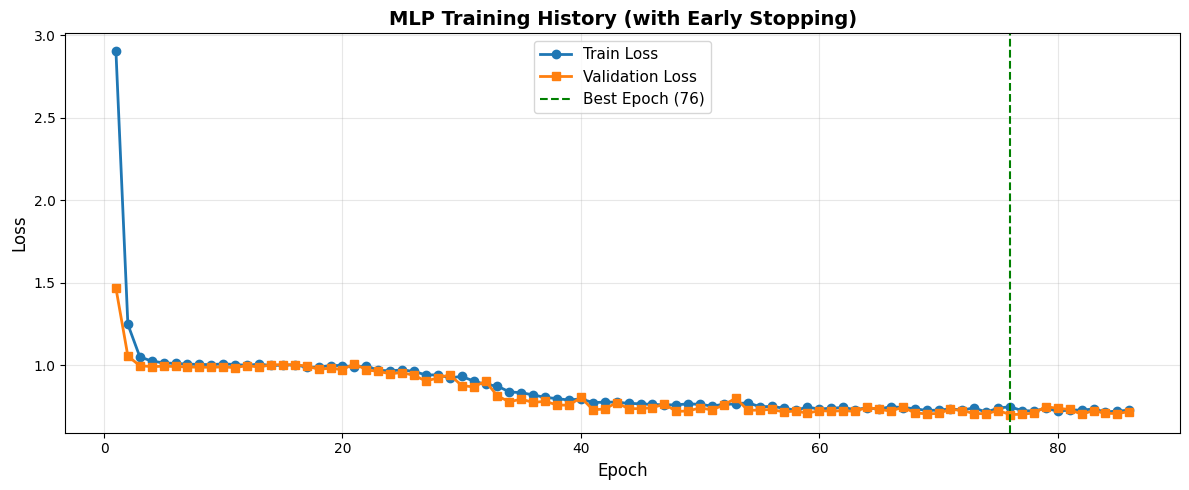


📊 Treinamento finalizado em 86 epochs


In [53]:
# Treinar MLP
print("\n" + "="*70)
print("TREINANDO MLP COM EARLY STOPPING")
print("="*70)

mlp_model = MLPClassifier(
    input_size=X_train.shape[1],
    hidden_sizes=[128, 64, 32],
    dropout_rates=[0.3, 0.2, 0.0]
)

mlp_model, history = train_mlp(
    mlp_model, train_loader, val_loader, 
    epochs=100, lr=0.001, early_stopping_patience=10
)

print(f"\n✅ MLP treinada com sucesso")

# Visualizar histórico de treinamento
fig, ax = plt.subplots(figsize=(12, 5))
epochs_range = range(1, len(history['train_loss']) + 1)
ax.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o', linewidth=2)
ax.plot(epochs_range, history['val_loss'], label='Validation Loss', marker='s', linewidth=2)
ax.axvline(x=history['best_epoch'] + 1, color='g', linestyle='--', label=f"Best Epoch ({history['best_epoch']+1})")
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('MLP Training History (with Early Stopping)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 Treinamento finalizado em {len(history['train_loss'])} epochs")

In [56]:
  # Avaliar MLP
from sklearn.metrics import roc_auc_score


def evaluate_mlp(model, X_test_torch_val, y_test_val, device='cpu'):
    model.eval()
    results = {}
    with torch.no_grad():
        logits = model(X_test_torch_val.to(device))
        y_proba_mlp = torch.sigmoid(logits).cpu().numpy().flatten()
        y_pred_mlp = (y_proba_mlp > 0.5).astype(int)
    
    results['MLP'] = {
        'accuracy': accuracy_score(y_test_val, y_pred_mlp),
        'precision': precision_score(y_test_val, y_pred_mlp, zero_division=0),
        'recall': recall_score(y_test_val, y_pred_mlp, zero_division=0),
        'f1': f1_score(y_test_val, y_pred_mlp, zero_division=0),
        'auc_roc': roc_auc_score(y_test_val, y_proba_mlp),
        'pr_auc': average_precision_score(y_test_val, y_proba_mlp),
        'y_pred': y_pred_mlp,
        'y_proba': y_proba_mlp
    }
    
    return results

In [57]:
evaluate_mlp(mlp_model, X_test_torch, y_test_torch)

{'MLP': {'accuracy': 0.7530163236337828,
  'precision': 0.5232974910394266,
  'recall': 0.7807486631016043,
  'f1': 0.6266094420600858,
  'auc_roc': np.float64(0.8517089049058358),
  'pr_auc': np.float64(0.6723420562340654),
  'y_pred': array([0, 1, 0, ..., 0, 0, 0], shape=(1409,)),
  'y_proba': array([0.16538975, 0.8724151 , 0.30034345, ..., 0.30714288, 0.05911143,
         0.11802431], shape=(1409,), dtype=float32)}}